---
# Metody liniowe
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from ucimlrepo import fetch_ucirepo 
from feature_engine.encoding import RareLabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr

In [2]:
sklearn.set_config(transform_output="pandas")
sklearn.__version__

'1.7.2'

# Przykład - [Computer Hardware](https://archive.ics.uci.edu/dataset/29/computer+hardware)

Zajmiemy się problemem regresji liniowej na przykładzie przewidywania względnej wydajności CPU

## Załadowanie danych

In [3]:
computer_hardware = fetch_ucirepo(id=29) 
X = computer_hardware.data.features 
y = computer_hardware.data.targets 

In [4]:
X.shape, len(y)

TypeError: object of type 'NoneType' has no len()

In [5]:
X

,VendorName,ModelName,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132
...,...,...,...,...,...,...,...,...,...,...
204,sperry,80/8,124,1000,8000,0,1,8,42,37
205,sperry,90/80-model-3,98,1000,8000,32,2,8,46,50
206,sratus,32,125,2000,8000,0,2,14,52,41
207,wang,vs-100,480,512,8000,32,0,0,67,47


Coś jest nie tak...

Wybieramy poprawną kolumnę dla `y` zgodnie z dokumentacją

In [6]:
y = X.pop('PRP')

Usuwamy też następujące kolumny ze zbioru `X`:
- `ERP` wartości uzyskane z modelu liniowego przez autorów (patrz dokumentacja)
- `ModelName` jedna z kolumn identyfikującej rekordy

In [7]:
X = X.drop(columns=['ERP', 'ModelName'])

In [8]:
X.shape, len(y)

((209, 7), 209)

## Wstępne przetwarzanie danych

### Brakujące dane

In [9]:
X[pd.isna(X).any(axis=1)]

,VendorName,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX


Nie ma brakujących danych. W takim razie dokonujemy "zepsucia" danych, a następnie używamy [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html)

In [10]:
X.loc[204, 'VendorName'] = np.nan

In [11]:
# podmieniamy dane za pomocą dominanty
# (w zasadzie najpopularniejsza metoda dla danych tekstowych)
simp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
X = simp.fit_transform(X)

In [12]:
# Czy podmiana zaszła zgodnie z oczekiwaniami?
assert X.loc[204, 'VendorName'] == X.VendorName.value_counts().index[0]

- Taką samą funkcjonalność możemy uzyskać za pomocą [pandas.DataFrame.fillna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html)
- Zaletą `SimpleImputer` jest to, że możemy go włączyć w piepline zob. [Imputing missing values before building an estimator](https://scikit-learn.org/stable/auto_examples/impute/plot_missing_values.html) i połączyć np. z metodą do skalowania / normalizacji
- Zobacz również API do [IterativeImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html)

### Zmienne kategoryczne

#### Usuwanie rzadkich kategorii
- Zauważmy, że `VendorName` posiada sporo kategorii, spośród których wiele jest rzadkich. Najlepiej połączyć je w jedną kategorię
- W tym celu użyjemy [RareLabelEncoder](https://feature-engine.trainindata.com/en/1.8.x/api_doc/encoding/RareLabelEncoder.html)
- **Uwaga:** jeśli mamy kilka większych grup, od których silnie zależy zmienna zależna, warto rozważyć [liniowy model efektów mieszanych](https://en.wikipedia.org/wiki/Mixed_model) - może się np. zdażyć, że zależność dla jednej grupy będzie dodatnia, a dla innej - ujemna. Wówczas zwykły model liniowy nie będzie w stanie uchwycić tego efektu

In [13]:
X.VendorName.nunique()

30

In [14]:
rare_label_encoder = RareLabelEncoder(n_categories=10, tol=0.05)

In [15]:
X['VendorName'] = rare_label_encoder.fit_transform(X[['VendorName']])

C:\Users\mateu\anaconda3\Lib\site-packages\feature_engine\variable_handling\_variable_type_checks.py:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  var = pd.to_datetime(column, utc=True)


In [16]:
X.VendorName.value_counts()

VendorName
Rare         107
ibm           33
nas           19
honeywell     13
ncr           13
siemens       12
sperry        12
Name: count, dtype: int64

Teraz możemy przejść do transformacji za pomocą one-hot encoding ([OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html))

#### One-hot encoding - przykład

Zacznijmy od prostego przykładu, żeby zrozumieć, jak działa *one-hot encoding*

In [17]:
enc = OneHotEncoder(drop='first', sparse_output=False)
XX = pd.DataFrame({
    "Color": ["Red", "Blue", "Green", "Red"],
    "Value": [10, 20, 15, 12]
})

In [18]:
XX

,Color,Value
0,Red,10
1,Blue,20
2,Green,15
3,Red,12


In [19]:
encoded = enc.fit_transform(XX[["Color"]])
pd.DataFrame(encoded, columns=enc.get_feature_names_out())

,Color_Green,Color_Red
0,0.0,1.0
1,0.0,0.0
2,1.0,0.0
3,0.0,1.0


#### One-hot encoding - nasze dane

A teraz wróćmy do naszego problemu

In [20]:
vendor_features = enc.fit_transform(X[['VendorName']])

In [21]:
X_enc = X.drop(columns='VendorName').join(vendor_features)

Podobną funkcjonalność ma [pandas.get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) z argumentem `drop_first=True`)

### Zmienne skorelowane

Rzućmy okiem na korelację dwóch grup cech:

In [22]:
# (Nowe) zmienne tekstowe
corrs_txt = vendor_features.corr()
# Zmienne numeryczne
corrs_num = X_enc.drop(columns=vendor_features.columns).corr()

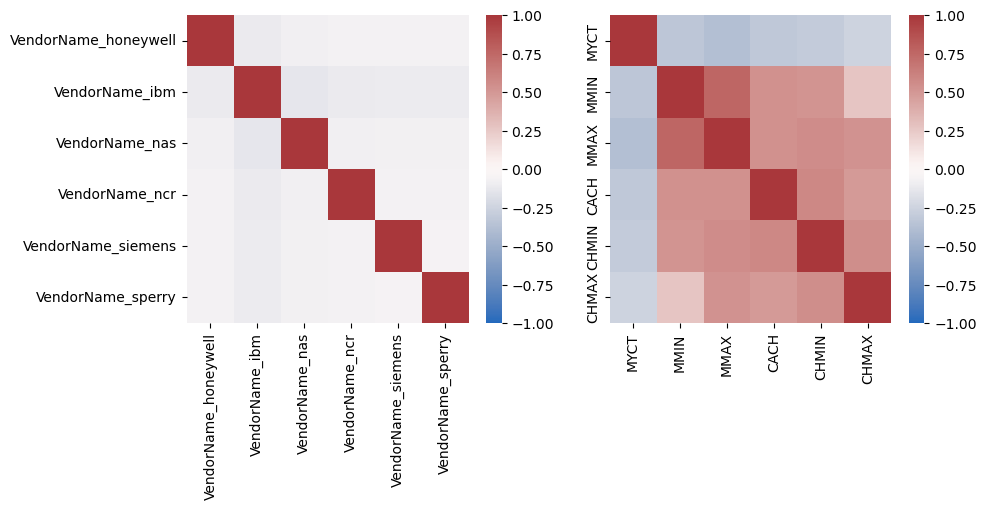

In [23]:
kwargs = {'cmap': 'vlag', 'vmin': -1, 'vmax': 1}
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(corrs_txt, ax=ax[0], **kwargs)
sns.heatmap(corrs_num, ax=ax[1], **kwargs)
plt.show()

- Jedynie jedna para ma całkiem wysoką korelację
- Usuńmy jedną zmienną z tej pary
- **Uwaga 1:** w rzeczywistych zastosowaniach lepiej wybrać wyższy próg np. 0.8-0.9 albo użyć regularyzacji
- **Uwaga 2:** nie musimy pisać własnej funkcji - możemy też użyć [SmartCorrelatedSelection](https://feature-engine.trainindata.com/en/1.8.x/user_guide/selection/SmartCorrelatedSelection.html), co jest zalecane

In [24]:
corrs_num.loc['MMIN', 'MMAX'].item()

0.758157347803723

In [25]:
def remove_highly_correlated_features(df, threshold=0.8):
    """
    Usuwa cechy o korelacji >= threshold, zachowując tę o wyższej wariancji

    Parametry:
        df (pd.DataFrame): dane wejściowe
        threshold (float): próg korelacji do usunięcia

    Zwraca:
        pd.DataFrame: dane ze zredukowanymi cechami
    """
    # Oblicz macierz korelacji i jej górny trójkąt
    corr_matrix = df.corr()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    # Identyfikacja cech do usunięcia
    to_drop = {
        column if df[column].var() < df[feature].var() else feature
        for column in upper_tri.columns
        for feature in upper_tri.index[upper_tri[column] >= threshold]
    }
    return df.drop(columns=to_drop)

In [26]:
X_enc_uncorr = remove_highly_correlated_features(X_enc, 0.7)

### Standardyzacja / normalizacja

- Generalnie, zawsze warto wypróbować zarówno standardyzację jak i normalizację (ale np. dla danych kompozycyjnych tj. proporcji to nie zadziała - wtedy trzeba użyć transformacji logatytmycznych typu *centered log-ratio*)
- Skalowaniu powinny podlegać przede wszystkim zmienne ciągłe
- Zmienne kategoryczne po tranformacji one-hot można, ale nie trzeba skalować (chyba że chcemy mieć bardziej klarowną interpretację wyrazu wolnego regresji)

In [27]:
scaler = StandardScaler()
X_enc_uncorr_scaled = scaler.fit_transform(X_enc_uncorr)

## Model liniowy

### Podział danych na zbiór treningowy i testowy

**Uwaga:** w rzeczywistości nasz zbiór testowy to zbiór walidacyjny tzn. zbiór wykorzystywany bezpośrednio do dostrajania hiperparametrów

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_enc_uncorr_scaled,
                                                    y, test_size=0.2, random_state=0)

### Trenujemy model

Zaczynamy od domyślnych hiperparametrów

In [29]:
reg_linear = LinearRegression()
reg_linear.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Sprawdzamy wyniki
- Generalnie, im więcej sposobów pomiaru wydajności modelu, tym lepiej, ale trzeba każdy z nich umieć zinterpretować!
- Poniżej stosujemy RMSE oraz MAE - pierwszy uwypukla błąd daleko od mediany, drugi - blisko mediany
- Podobnie, sprawdzamy współczynniki korelacji Pearsona i Spermana dla wartości przewidzianych i oczekiwanych, żeby zobaczyć, czy trend dla obu jest podobny
- Wykres `y` przeciw `y_pred` może być również pomocny m.in. w zdiagnozowaniu obszaru (obszarów), gdzie model radzi sobie gorzej

#### Przewidywania modelu

In [30]:
y_pred_train = reg_linear.predict(X_train)
y_pred_test  = reg_linear.predict(X_test)

#### RMSE, MAE

In [31]:
root_mean_squared_error(y_train, y_pred_train), root_mean_squared_error(y_test, y_pred_test)

(68.952895638737, 61.236155731731984)

In [32]:
mean_absolute_error(y_train, y_pred_train), mean_absolute_error(y_test, y_pred_test)

(44.17005855291143, 47.34500454986593)

#### Współczynniki korelacji

In [33]:
pearsonr(y_train, y_pred_train)[0], pearsonr(y_test, y_pred_test)[0]

(np.float64(0.9122083180373266), np.float64(0.8823822587966449))

In [34]:
spearmanr(y_train, y_pred_train)[0], spearmanr(y_test, y_pred_test)[0]

(np.float64(0.8451987552961482), np.float64(0.8714291567282909))

Na pierwszy rzut oka, wyniki są całkiej niezłe, ale bardzo rzadko domyślne hiperparametry są tymi optymalnymi

## Baseline: DummyRegressor (średnia jako predykcja)
Porównujemy model liniowy do prostego baseline: zawsze przewiduj średnią z treningu.

In [35]:
from sklearn.dummy import DummyRegressor

In [36]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

y_pred_train_dummy = dummy.predict(X_train)
y_pred_test_dummy  = dummy.predict(X_test)

print("DUMMY RMSE train/test:",
      root_mean_squared_error(y_train, y_pred_train_dummy),
      root_mean_squared_error(y_test,  y_pred_test_dummy))

print("DUMMY MAE train/test:",
      mean_absolute_error(y_train, y_pred_train_dummy),
      mean_absolute_error(y_test,  y_pred_test_dummy))

DUMMY RMSE train/test: 168.28996594982087 124.50393060061275
DUMMY MAE train/test: 98.71755889418765 88.42743085258056


## Kontrola „data leakage”: skalowanie dopasowane tylko na train/test

W tej sekcji robimy skalowanie poprawnie: `fit` tylko na treningu, a `transform` na treningu i teście.
Porównamy wynik z poprzednim podejściem.

In [37]:
# POPRAWNIE: split na danych nieskalowanych
X_train_df, X_test_df, y_train2, y_test2 = train_test_split(
    X_enc_uncorr, y, test_size=0.2, random_state=0
)

scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train_df)
X_test_scaled2  = scaler2.transform(X_test_df)

reg_linear2 = LinearRegression()
reg_linear2.fit(X_train_scaled2, y_train2)

y_pred_train2 = reg_linear2.predict(X_train_scaled2)
y_pred_test2  = reg_linear2.predict(X_test_scaled2)

print("Linear (no leakage) RMSE train/test:",
      root_mean_squared_error(y_train2, y_pred_train2),
      root_mean_squared_error(y_test2,  y_pred_test2))

print("Linear (no leakage) MAE train/test:",
      mean_absolute_error(y_train2, y_pred_train2),
      mean_absolute_error(y_test2,  y_pred_test2))

Linear (no leakage) RMSE train/test: 68.95289563873699 61.23615573173197
Linear (no leakage) MAE train/test: 44.17005855291137 47.345004549865926



### W teorii leakage, ale czy w praktyce wpłynałtutaj?

Data leakage to:
Używanie jakiejkolwiek informacji z testu w procesie uczenia.
Nie musi to być y.

Wystarczy, że użyjesz np:
 - średniej,
 - wariancji,
 - korelacji,
 - czegokolwiek dopasowanego na całości.

To już jest przeciek.

### Ridge / Lasso / ElasticNet + dobór hiperparametrów przez CV
Dobieramy `alpha` walidacją krzyżową (na treningu), a potem raportujemy wynik na teście.
Używamy Pipeline, żeby uniknąć leakage (scaler jest uczony tylko w foldach treningowych).

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet

In [ ]:
# Użyjemy danych "surowych" po OneHot + usunięciu korelacji (X_enc_uncorr),
# a skalowanie tym razem zrobimy w Pipeline.

X_train_df, X_test_df, y_train3, y_test3 = train_test_split(
    X_enc_uncorr, y, test_size=0.2, random_state=0
)

cv = KFold(n_splits=5, shuffle=True, random_state=0)
alphas = np.logspace(-4, 3, 20)

models = {
    "Linear": (LinearRegression(), {}),  # brak hiperparametrów
    "Ridge": (Ridge(), {"model__alpha": alphas}),  # Ridge(α→0)≈LinearRegression
    "Lasso": (Lasso(max_iter=20000), {"model__alpha": alphas}),
    "ElasticNet": (ElasticNet(max_iter=20000), {
        "model__alpha": alphas,
        "model__l1_ratio": [0.2, 0.5, 0.8]
    }),
}

results = []

best_estimators = {}

for name, (model, params) in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    gs = GridSearchCV(
        pipe,
        param_grid=params,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )
    gs.fit(X_train_df, y_train3)

    best_estimators[name] = gs.best_estimator_

    y_pred_train = gs.best_estimator_.predict(X_train_df)
    y_pred_test  = gs.best_estimator_.predict(X_test_df)

    results.append({
        "model": name,
        "best_params": gs.best_params_,
        "RMSE_train": root_mean_squared_error(y_train3, y_pred_train),
        "RMSE_test":  root_mean_squared_error(y_test3,  y_pred_test),
        "MAE_train":  mean_absolute_error(y_train3, y_pred_train),
        "MAE_test":   mean_absolute_error(y_test3,  y_pred_test),
    })

pd.DataFrame(results).sort_values("RMSE_test")

### Porównanie współczynników (Linear vs Ridge vs Lasso)
Patrzymy, które cechy są najważniejsze oraz ile współczynników Lasso wyzerowało.
(Uwaga: współczynniki są dla cech po standaryzacji w Pipeline.)

In [ ]:
# Dopasujmy też "Linear w pipeline", żeby porównanie było fair (z tym samym skalowaniem)
lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
lin_pipe.fit(X_train_df, y_train3)

coefs = pd.DataFrame({
    "feature": X_enc_uncorr.columns,
    "Linear": lin_pipe.named_steps["model"].coef_,
    "Ridge":  best_estimators["Ridge"].named_steps["model"].coef_,
    "Lasso":  best_estimators["Lasso"].named_steps["model"].coef_,
})

coefs["abs_Linear"] = coefs["Linear"].abs()
coefs = coefs.sort_values("abs_Linear", ascending=False)

print("Liczba wyzerowanych wag (Lasso):",
      int((coefs["Lasso"] == 0).sum()), "/", len(coefs))

coefs.drop(columns=["abs_Linear"]).head(15)